In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.linear_model import LogisticRegression
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

train_data = pd.read_csv("../csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=["Economica", "Media", "Cara"], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data[["PriceCategory", "SalePrice"]]

139000.0 189893.00000000006 755000


,PriceCategory,SalePrice
0,Cara,208500
1,Media,181500
2,Cara,223500
3,Media,140000
4,Cara,250000
...,...,...
1455,Media,175000
1456,Cara,210000
1457,Cara,266500
1458,Media,142125


In [45]:
train_data.shape

(1460, 82)

In [46]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

### Columnas que NO sirven:
- Id - identificador único, no aporta valor predictivo.

- Alley, PoolQC, Fence, MiscFeature - demasiados valores nulos (>75%).

- Utilities - tiene casi un solo valor (AllPub), no aporta variabilidad.

- FireplaceQu, GarageYrBlt, GarageQual, GarageCond - muchos nulos y posible colinealidad con otras características más completas.

In [47]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond"],axis=1, inplace=True)

In [48]:
print(train_data.dtypes.tolist())

[dtype('int64'), dtype('O'), dtype('float64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('int64'),

### Estas columnas tienen demasiadas categorías

- Neighborhood (25)
- Condition1 (9)
- Condition2 (8)
- RoofMatl (8)
- Exterior1st (15)
- Exterior2nd (16)

In [49]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [50]:
columns_to_encode = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
    'BldgType', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish',
    'PavedDrive', 'SaleType', 'SaleCondition'
]
train_data.drop(columns=columns_to_encode, inplace=True)

In [51]:
dummies = pd.get_dummies(train_data['PriceCategory'], dtype=int)
dummies.head()

,Economica,Media,Cara
0,0,0,1
1,0,1,0
2,0,0,1
3,0,1,0
4,0,0,1


In [52]:
datos = pd.concat([train_data,dummies], axis=1) 
datos.head()

,MSSubClass,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,MasVnrArea,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,PriceCategory,Economica,Media,Cara
0,60,65.0,8450,2Story,7,5,2003,2003,Gable,196.0,...,0,0,0,2,2008,208500,Cara,0,0,1
1,20,80.0,9600,1Story,6,8,1976,1976,Gable,0.0,...,0,0,0,5,2007,181500,Media,0,1,0
2,60,68.0,11250,2Story,7,5,2001,2002,Gable,162.0,...,0,0,0,9,2008,223500,Cara,0,0,1
3,70,60.0,9550,2Story,7,5,1915,1970,Gable,0.0,...,0,0,0,2,2006,140000,Media,0,1,0
4,60,84.0,14260,2Story,8,5,2000,2000,Gable,350.0,...,0,0,0,12,2008,250000,Cara,0,0,1


In [53]:
Economica = datos.pop("Economica") 
Media = datos.pop("Media")
Cara = datos.pop("Cara")
datos.pop("PriceCategory")

print(Economica.head())
print(Media.head())
print(Cara.head())
print(datos.head())

0    0
1    0
2    0
3    0
4    0
Name: Economica, dtype: int64
0    0
1    1
2    0
3    1
4    0
Name: Media, dtype: int64
0    1
1    0
2    1
3    0
4    1
Name: Cara, dtype: int64
   MSSubClass  LotFrontage  LotArea HouseStyle  OverallQual  OverallCond  \
0          60         65.0     8450     2Story            7            5   
1          20         80.0     9600     1Story            6            8   
2          60         68.0    11250     2Story            7            5   
3          70         60.0     9550     2Story            7            5   
4          60         84.0    14260     2Story            8            5   

   YearBuilt  YearRemodAdd RoofStyle  MasVnrArea  ...  WoodDeckSF  \
0       2003          2003     Gable       196.0  ...           0   
1       1976          1976     Gable         0.0  ...         298   
2       2001          2002     Gable       162.0  ...           0   
3       1915          1970     Gable         0.0  ...           0   
4       2000

In [54]:
categorical_cols = datos.select_dtypes(include=["object"]).columns
datos = pd.get_dummies(datos, columns=categorical_cols, drop_first=True)

# Rellenar NaNs con la mediana de cada columna
datos.fillna(datos.median(numeric_only=True), inplace=True)

# Convertir todos los datos a tipo int
datos = datos.astype(int)

In [55]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         1460 non-null   int64
 1   LotFrontage        1460 non-null   int64
 2   LotArea            1460 non-null   int64
 3   OverallQual        1460 non-null   int64
 4   OverallCond        1460 non-null   int64
 5   YearBuilt          1460 non-null   int64
 6   YearRemodAdd       1460 non-null   int64
 7   MasVnrArea         1460 non-null   int64
 8   BsmtFinSF1         1460 non-null   int64
 9   BsmtFinSF2         1460 non-null   int64
 10  BsmtUnfSF          1460 non-null   int64
 11  TotalBsmtSF        1460 non-null   int64
 12  1stFlrSF           1460 non-null   int64
 13  2ndFlrSF           1460 non-null   int64
 14  LowQualFinSF       1460 non-null   int64
 15  GrLivArea          1460 non-null   int64
 16  BsmtFullBath       1460 non-null   int64
 17  BsmtHalfBath  

## Correlacion

In [56]:
corr_matrix = datos.corr()

# Convertir la matriz en pares únicos (triangular inferior, sin diagonal)
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={0: "Correlation", "level_0": "Var1", "level_1": "Var2"})
)

# Ordenar por valor absoluto de la correlación (de mayor a menor)
sorted_corr = corr_pairs.reindex(corr_pairs.Correlation.abs().sort_values(ascending=False).index)

# Mostrar los 50 pares más correlacionados (puedes ajustar el número)
print(sorted_corr.head(50))

                   Var1               Var2  Correlation
1033      RoofStyle_Hip    RoofStyle_Gable    -0.933462
324          GarageArea         GarageCars     0.882475
246        TotRmsAbvGrd          GrLivArea     0.825489
77             1stFlrSF        TotalBsmtSF     0.819530
793   HouseStyle_2Story           2ndFlrSF     0.809150
598           SalePrice        OverallQual     0.790982
679   HouseStyle_1Story           2ndFlrSF    -0.788749
610           SalePrice          GrLivArea     0.708624
118           GrLivArea           2ndFlrSF     0.687501
251        TotRmsAbvGrd       BedroomAbvGr     0.676620
817   HouseStyle_2Story  HouseStyle_1Story    -0.658517
128        BsmtFullBath         BsmtFinSF1     0.649212
619           SalePrice         GarageCars     0.640409
168            FullBath          GrLivArea     0.630012
620           SalePrice         GarageArea     0.623431
799   HouseStyle_2Story           HalfBath     0.623399
244        TotRmsAbvGrd           2ndFlrSF     0

### Separemos en Conjuntos de Entrenamiento (70%) y Prueba (30%) 

In [57]:
y = Media #La variable respuesta
X = datos #El resto de los datos
random.seed(123)

In [58]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

In [59]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 529 to 383
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         1021 non-null   int64
 1   LotFrontage        1021 non-null   int64
 2   LotArea            1021 non-null   int64
 3   OverallQual        1021 non-null   int64
 4   OverallCond        1021 non-null   int64
 5   YearBuilt          1021 non-null   int64
 6   YearRemodAdd       1021 non-null   int64
 7   MasVnrArea         1021 non-null   int64
 8   BsmtFinSF1         1021 non-null   int64
 9   BsmtFinSF2         1021 non-null   int64
 10  BsmtUnfSF          1021 non-null   int64
 11  TotalBsmtSF        1021 non-null   int64
 12  1stFlrSF           1021 non-null   int64
 13  2ndFlrSF           1021 non-null   int64
 14  LowQualFinSF       1021 non-null   int64
 15  GrLivArea          1021 non-null   int64
 16  BsmtFullBath       1021 non-null   int64
 17  BsmtHalfBath      

In [60]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438 entries, 1195 to 1044
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         438 non-null    int64
 1   LotFrontage        438 non-null    int64
 2   LotArea            438 non-null    int64
 3   OverallQual        438 non-null    int64
 4   OverallCond        438 non-null    int64
 5   YearBuilt          438 non-null    int64
 6   YearRemodAdd       438 non-null    int64
 7   MasVnrArea         438 non-null    int64
 8   BsmtFinSF1         438 non-null    int64
 9   BsmtFinSF2         438 non-null    int64
 10  BsmtUnfSF          438 non-null    int64
 11  TotalBsmtSF        438 non-null    int64
 12  1stFlrSF           438 non-null    int64
 13  2ndFlrSF           438 non-null    int64
 14  LowQualFinSF       438 non-null    int64
 15  GrLivArea          438 non-null    int64
 16  BsmtFullBath       438 non-null    int64
 17  BsmtHalfBath     

# Creacion modelo regresion logistica

In [61]:
logReg = LogisticRegression(solver='liblinear')
logReg.fit(X_train,y_train)
y_pred = logReg.predict(X_test)
y_proba = logReg.predict_proba(X_test)[:,1] # vector de probabilidades
cm = confusion_matrix(y_test,y_pred)

In [62]:
y_proba

array([0.35880339, 0.37868207, 0.38857843, 0.18511746, 0.40593826,
       0.58147617, 0.43830286, 0.35935122, 0.32395939, 0.39073008,
       0.35222461, 0.04066517, 0.38524134, 0.2191799 , 0.35830392,
       0.15275625, 0.43810937, 0.20747025, 0.19883892, 0.27012525,
       0.39025446, 0.24422307, 0.34569254, 0.44316953, 0.25118043,
       0.29298256, 0.34314619, 0.14771384, 0.11636546, 0.33302213,
       0.26217579, 0.3696879 , 0.39130792, 0.14222458, 0.22167565,
       0.3621097 , 0.31049893, 0.36048957, 0.2569369 , 0.14154235,
       0.44907892, 0.38493043, 0.30350533, 0.2879813 , 0.3685584 ,
       0.36172265, 0.46889421, 0.26503093, 0.37363117, 0.13353152,
       0.33658751, 0.03432801, 0.2785676 , 0.18096087, 0.36684069,
       0.06308599, 0.43437304, 0.17402037, 0.10001178, 0.28536719,
       0.30668483, 0.32759839, 0.33255605, 0.56526729, 0.16188777,
       0.31972417, 0.19409049, 0.13655365, 0.31633255, 0.40158954,
       0.37152355, 0.22106143, 0.36774317, 0.37216551, 0.50827

In [63]:
y_test

1195    1
1102    0
986     0
1132    0
1162    0
       ..
398     0
405     1
900     0
629     1
1044    0
Name: Media, Length: 438, dtype: int64

In [64]:
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión para detectar Media\n',cm)
print('Accuracy: ',accuracy)

Matriz de confusión para detectar Media
 [[264  27]
 [128  19]]
Accuracy:  0.6461187214611872


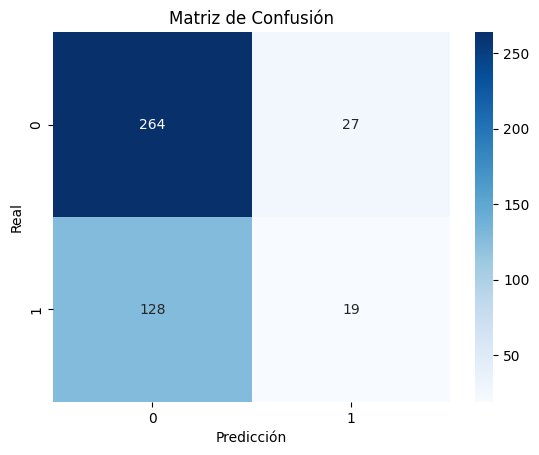

In [65]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#### AUROC

Área bajo la curva ROC (AUROC): 0.6789863711807748


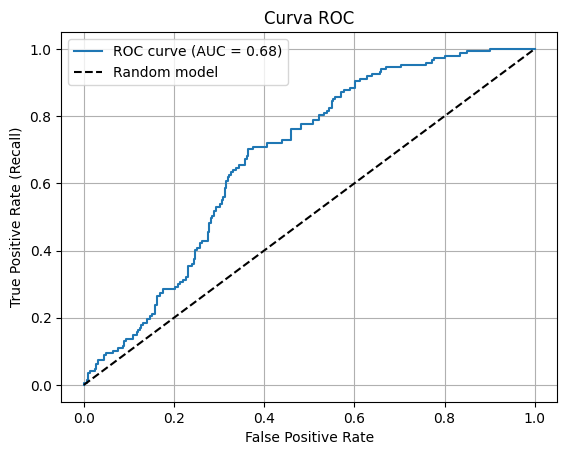

In [66]:
# Cálculo del AUROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auroc = roc_auc_score(y_test, y_proba)
print("Área bajo la curva ROC (AUROC):", auroc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auroc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()

## Juguemos con el umbral

In [67]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=logReg, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X, y)

c:\Users\thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
c:\Users\thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
c:\Users\thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.5176259529350231. Increase the number of iterations.
  warnings.warn(


In [68]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

best_model = grid_result.best_estimator_
print(grid_search)


Best: 0.718265 using {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.717580 (0.032208) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.639498 (0.022334) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.655708 (0.024564) with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.718037 (0.032995) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.640183 (0.023310) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.655479 (0.024705) with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.718265 (0.029737) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.639726 (0.023766) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.652511 (0.023722) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.712785 (0.028126) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.637900 (0.024295) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.655936 (0.023903) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.688813 (0.025177) wit

In [69]:
# Obtener probabilidades del modelo
y_probs = best_model.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Encontrar el umbral con mejor balance tpr - fpr (Youden's J statistic)
j_scores = tpr - fpr
best_threshold = thresholds[j_scores.argmax()]

print(f"Mejor umbral según Youden's J: {best_threshold:.2f}")

Mejor umbral según Youden's J: 0.33


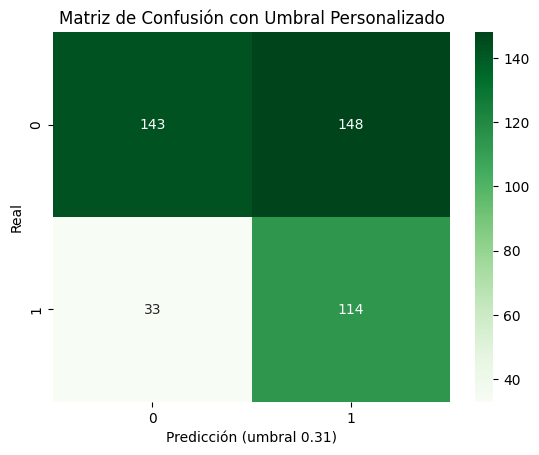

In [70]:
# Usar umbral distinto a 0.5
custom_threshold = 0.31
custom_preds = (y_proba >= custom_threshold).astype(int)

# Nueva matriz de confusión
cm_custom = confusion_matrix(y_test, custom_preds)
sns.heatmap(cm_custom, annot=True, cmap='Greens', fmt='d')
plt.xlabel("Predicción (umbral 0.31)")
plt.ylabel("Real")
plt.title("Matriz de Confusión con Umbral Personalizado")
plt.show()

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       291
           1       0.77      0.48      0.59       147

    accuracy                           0.78       438
   macro avg       0.78      0.71      0.72       438
weighted avg       0.78      0.78      0.76       438



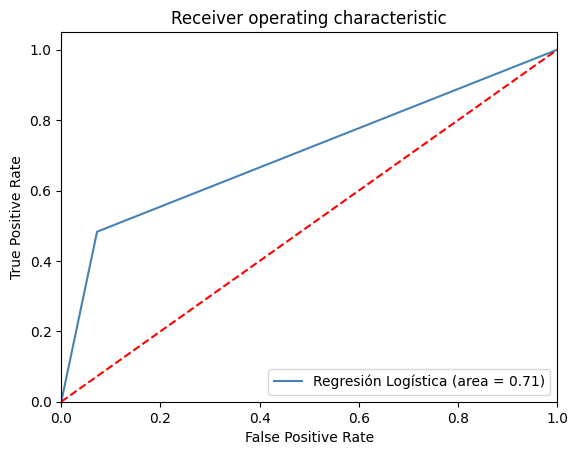

In [71]:
ypred = best_model.predict(X_test)
print(classification_report(y_test,ypred))

logit_roc_auc = roc_auc_score(y_test, ypred)
fpr, tpr, thresholds = roc_curve(y_test, ypred)
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()